# Fig 13.2


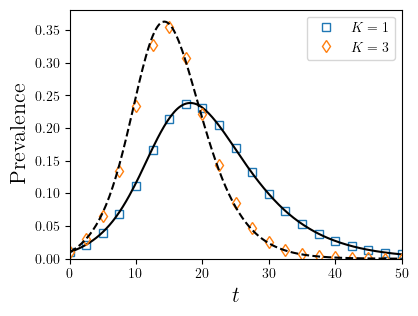

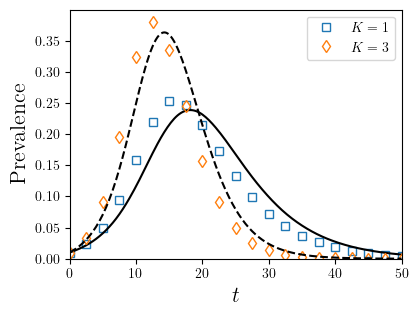

In [1]:
import networkx as nx
import EoN
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc
from collections import defaultdict
from scipy.integrate import solve_ivp

#commands to make legend be in LaTeX font
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)



def dSIkR(t, y, tau, gamma, K, n):
    S = y[0]
    I = y[1:K+1]
    R = y[K+1]
    
    SS = y[2 + K]
    SI = y[3 + K : 3 + 2*K]
    SR = y[3 + 2*K]

    zeta = (n-1)/n 
    if S == 0.0:
        raise ZeroDivisionError("S(t)=0 caused division by S in closures.")

    sum_SI = np.sum(SI)
    sum_SSI = zeta * SS * sum_SI / S
    sum_IiSIj_vec = zeta * SI * sum_SI / S
    sum_RSI = zeta * SR * sum_SI / S

    dS = -tau * sum_SI

    dI = np.zeros(K)
    dI[0] = tau * sum_SI - K * gamma * I[0]
    if K > 1:
        dI[1:] = K * gamma * I[:-1] - K * gamma * I[1:]

    dR = K * gamma * I[-1]
    dSS = -2.0 * tau * sum_SSI

    dSI = np.zeros(K)
    dSI[0] = -(tau + K * gamma) * SI[0] + tau * (sum_SSI - sum_IiSIj_vec[0])
    if K > 1:
        dSI[1:] = -(tau + K * gamma) * SI[1:] + K * gamma * SI[:-1] - tau * sum_IiSIj_vec[1:]

    dSR = K * gamma * SI[-1] - tau * sum_RSI

    dy = np.zeros_like(y)
    dy[0] = dS
    dy[1 : 1 + K] = dI
    dy[1 + K] = dR
    dy[2 + K] = dSS
    dy[3 + K : 3 + 2*K] = dSI
    dy[3 + 2*K] = dSR
    return dy

rng = np.random.default_rng(12345) 

tmin = 0
tmax = 50
report_times = np.linspace(tmin, tmax, 21)

N = 100000
gamma = 1/5.5
ntau = 0.545
n = 10
tau = ntau/n
rho = 0.01
initial_I_count = int(rho*N)

zeta = (n-1)/n

G_reg = nx.random_regular_graph(n, N)
G_ER = nx.fast_gnp_random_graph(N, n/(N-1))



H_si1r = nx.DiGraph()
H_si1r.add_edge('I1', 'R', rate = gamma)

J_si1r = nx.DiGraph()
J_si1r.add_edge(('I1', 'S'), ('I1', 'I1'), rate = tau)

H_si3r = nx.DiGraph()
H_si3r.add_weighted_edges_from([ ('I1', 'I2', gamma*3), ('I2', 'I3', gamma*3), ('I3', 'R', gamma*3)], weight='rate')

J_si3r = nx.DiGraph()
J_si3r.add_weighted_edges_from([(('I1', 'S'), ('I1', 'I1'), tau), (('I2', 'S'), ('I2', 'I1'), tau), (('I3', 'S'), ('I3', 'I1'), tau)], weight = 'rate')

return_statuses = ['S', 'I1', 'I2', 'I3', 'R']
for G, label in zip((G_reg, G_ER), ('a', 'b')):
    plt.figure(figsize=(4,3))
    plt.subplots_adjust(left=0.15, right=0.98, top=0.98, bottom=0.15)

    for K, H, J, symbol in zip([1, 3], [H_si1r, H_si3r], [J_si1r, J_si3r], ['s', 'd']):
        IC = defaultdict(lambda: 'S')
        for node in range(initial_I_count):
            IC[node] = 'I1'
            
        times, S, I1, I2, I3, R, = EoN.Gillespie_simple_contagion(G, H, J, IC, return_statuses=return_statuses)
        report_I = EoN.subsample(report_times, times, I1+I2+I3)
        plt.plot(report_times, report_I/N, symbol, label = '$K={}$'.format(K), markerfacecolor='none')
        S_0 = N*(1-rho)
        I_0 = np.zeros(K)
        I_0[0] = N*rho
        R_0 = 0
        SS_0 = n*N*(1-rho)**2
        SI_0 = np.zeros(K)
        SI_0[0] = n*N*(1-rho)*rho
        SR_0 = 0
        IC = np.array([S_0, *I_0, R_0, SS_0, *SI_0, SR_0]) #The * unpacks the list
        
        sol = solve_ivp(dSIkR, (tmin, tmax), IC, args=(tau, gamma, K, n), dense_output=True)
        ts = np.linspace(tmin, tmax, 201)
        ys = sol.sol(ts)
        I = ys[1 : 1 + K, :]
        if K == 1:
            plt.plot(ts, I[0]/N, '-', color='k')
        else:
            plt.plot(ts, np.sum(I, axis=0)/N, '--', color='k')
        #t, S, I1, I2, I3, R = #EoN.Simple_contagion_
        #plt.plot(t, (I1+I2+I3)/N, label = f'$K=${K}')
    plt.xlabel('$t$', fontsize=16)
    plt.ylabel('Prevalence', fontsize=16)
    plt.legend()
    plt.xlim(xmin=tmin, xmax=tmax)
    plt.ylim(ymin=0)
    plt.savefig('fig13p2{}.png'.format(label))

# Figure 13.4

n= 5   zeta= 0.8
n= 10   zeta= 0.9
n= 15   zeta= 0.9333333333333333
0.6140496753092126
0.6116878249349205


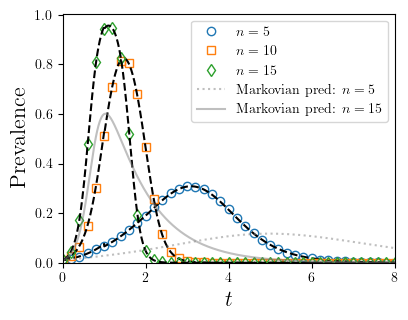

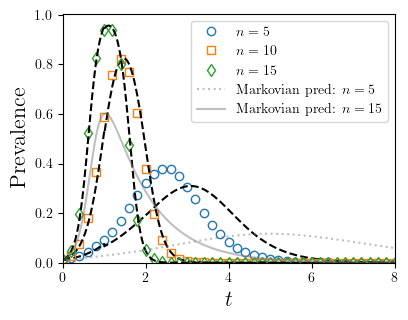

In [2]:
# Solve:
#  d[S]/dt  = -tau * [SI](t)
#  d[I]/dt  =  tau * [SI](t) - tau * [SI](t - sigma)
#  d[SS]/dt = -2*tau*zeta * [SS](t)*[SI](t)/[S](t)
#  d[SI]/dt = -tau*[SI](t)
#             -tau*zeta*( [SI]^2/[S] - [SS]*[SI]/[S] )
#             -tau*zeta * [SS](t-σ)[SI](t-σ)/[S](t-σ) * exp( -∫_{t-σ}^{t}([SI](u)*tau*zeta/[S](u) + tau)du )
# with auxiliary J(t) = int_{t-σ}^{t}(... ) du so exp( -J(t) )

import numpy as np
import networkx as nx 
import EoN
import math
import matplotlib.pyplot as plt
from jitcdde import y, t, jitcdde
#Note the use of jitcdde may require
#installing some C++ compilers.

from matplotlib import rc

#commands to make legend be in LaTeX font
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)

from dataclasses import dataclass
from typing import Callable, List, Tuple
from scipy.integrate import solve_ivp


@dataclass
class PastSolution:
    # Holds piecewise dense solutions: (t_start, t_end, sol_fun)
    pieces: List[Tuple[float, float, Callable[[float], np.ndarray]]]

    def value(self, t_query: float,
              S_hist: float, I_hist: float, SS_hist: float, SI_hist: float, J_hist: float) -> np.ndarray:
        """Return y(t_query). For t_query<0 return constant history."""
        if t_query < 0.0:
            return np.array([S_hist, I_hist, SS_hist, SI_hist, J_hist], dtype=float)
        for (a, b, sol) in self.pieces:
            if a - 1e-12 <= t_query <= b + 1e-12:
                return sol(t_query).ravel()
        # Clamp tiny FP drift at segment edges
        if self.pieces:
            (a, b, sol) = self.pieces[-1]
            if a - 1e-9 <= t_query <= b + 1e-9:
                return sol(min(max(t_query, a), b)).ravel()
        raise ValueError(f"No past solution available for t={t_query:.6f}")

def dde_rhs(t, y, past: PastSolution, tau, zeta, sigma,
            S_hist, I_hist, SS_hist, SI_hist, J_hist):
    S, I, SS, SI, J = y
    t_lag = t - sigma
    S_l, I_l, SS_l, SI_l, J_l = past.value(t_lag, S_hist, I_hist, SS_hist, SI_hist, J_hist)

    dS  = -tau * SI
    dI  =  tau * SI - tau * SI_l
    dSS = -2.0 * tau * zeta * SS * SI / S

    exp_factor = math.exp(-J)
    dSI = (
        -tau * SI
        -tau * zeta * ( (SI*SI)/S - (SS*SI)/S)
        -tau * zeta * (SS_l * SI_l / S_l) * exp_factor
    )
    dJ = tau * zeta * (SI/S - SI_l/S_l)
    return np.array([dS, dI, dSS, dSI, dJ], dtype=float)

def solve_pairwise_dde(y0, T_end, sigma, tau, zeta,
                       S_hist, I_hist, SS_hist, SI_hist, J_hist,
                       seed_I0, seed_SI0,     # NEW: seeds to remove at t = sigma
                       rtol=1e-6, atol=1e-9):
    """
    Method-of-steps: integrate [0, sigma], [sigma, 2 sigma], ...
    Applies a jump at t = sigma:
      I  -> I  - seed_I0
      SI -> SI - seed_SI0 * exp(-J(σ-))
    """
    past = PastSolution(pieces=[])
    # seed a degenerate piece at t=0 so past.value(0.0) works
    past.pieces.append((0.0, 0.0, lambda tt: y0.copy()))

    t0 = 0.0
    y_last = y0.copy()
    k_max = int(np.ceil(T_end / sigma))

    for k in range(k_max):
        t1 = min((k+1)*sigma, T_end)

        rhs = lambda t, y: dde_rhs(t, y, past, tau, zeta, sigma,
                                   S_hist, I_hist, SS_hist, SI_hist, J_hist)
        sol = solve_ivp(rhs, (t0, t1), y_last, method="RK45",
                        dense_output=True, rtol=rtol, atol=atol,
                        max_step=min(0.1, (t1 - t0)))
        if not sol.success:
            raise RuntimeError(f"SciPy solve failed on [{t0},{t1}]: {sol.message}")

        # store the pre-jump segment
        past.pieces.append((t0, t1, sol.sol))

        # end-of-segment state (right before any jump)
        y_minus = sol.y[:, -1].copy()

        # --- Apply the jump at t = sigma (once, after the first segment) ---
        if abs(t1 - sigma) <= 1e-12:
            J_sigma_minus = y_minus[IDX_J]
            y_minus[IDX_I]  = max(0.0, y_minus[IDX_I]  - seed_I0)
            y_minus[IDX_SI] = max(0.0, y_minus[IDX_SI] - seed_SI0 * math.exp(-J_sigma_minus))
            # S, SS, J remain continuous

            # register a zero-length piece at t = sigma with post-jump state
            y_after = y_minus.copy()
            past.pieces.append((t1, t1, lambda tt, y=y_after: y))

        # advance to next segment from the (possibly jumped) state
        t0 = t1
        y_last = y_minus

        if t1 >= T_end - 1e-12:
            break

    return past

rng = np.random.default_rng(12345)

def trans_and_rec_time_fxn(u, sus_nbrs, tau, sigma):
    trans_delay_dict = {}
    for v in sus_nbrs:
        delay = rng.exponential(1/tau)
        if delay < sigma:
            trans_delay_dict[v] = delay
    return trans_delay_dict, sigma


# -----------------------
# Indices for readability
# -----------------------
IDX_S  = 0
IDX_I  = 1
IDX_SS = 2
IDX_SI = 3
IDX_J  = 4

N = 100000
rho = 0.01

tau   = 0.55       # transmission parameter
sigma = 1.0        # fixed delay

tmin = 0
tmax = 8

# fig, axes = plt.subplots(1,2, figsize=(8,3))#plt.subplots(2,2,figsize=(8,6))
# axes=axes.flatten()
# fig.subplots_adjust(left=0.08, right=0.99, wspace=0.18, bottom=0.15, top=0.97 )# Increase right, decrease wspace for wider axes
#plt.subplots_adjust(left=0.1, right=0.98, top=0.98, bottom=0.08)
axes = []
figs = []
fig, ax = plt.subplots(1,1, figsize=(4,3))
plt.subplots_adjust(left=0.15, right=0.98, top=0.98, bottom=0.15)
axes.append(ax)
figs.append(fig)
fig, ax = plt.subplots(1,1, figsize=(4,3))
plt.subplots_adjust(left=0.15, right=0.98, top=0.98, bottom=0.15)
axes.append(ax)
figs.append(fig)
report_times = np.linspace(tmin, tmax, 41)
for n, symbol in zip([5, 10, 15], ['o', 's', 'd']):
    G_reg = nx.random_regular_graph(n, N)
    G_ER = nx.fast_gnp_random_graph(N, n/(N-1))
    zeta = (n-1)/n
    print("n=", n, "  zeta=", zeta)

    for G, ax in zip([G_reg, G_ER], axes):
        times, S, I, R = EoN.fast_nonMarkov_SIR(G, trans_and_rec_time_fxn=trans_and_rec_time_fxn, trans_and_rec_time_args = (tau, sigma), rng = rng, rho = rho)
        report_I = EoN.subsample(report_times, times, I)
        ax.plot(report_times, report_I/N, symbol, label = "$n={}$".format(n), markerfacecolor='none')
        
        
        # ---- DDE via SciPy method-of-steps (no JiTCDDE) ----

        # Constant prehistory for t <= 0
        S_hist  = G.order()               # all susceptible
        I_hist  = 0
        SS_hist = 2*G.size()
        SI_hist = 0
        # J integrates (tau*zeta*SI/S + tau) over the last sigma units.
        # With SI_hist=0, this is sigma * tau (not zero).
        J_hist  = sigma * (tau*zeta*(SI_hist/(S_hist)) + tau)

        # Jump at t = 0+: set initial state after seeding rho
        S0  = N*(1 - rho)
        I0  = N*rho
        SS0 = 2*G.size() * (1 - rho) * (1 - rho)
        SI0 = 2*G.size() * (1 - rho) * rho
        J0  = J_hist  # IMPORTANT: integral still over [-sigma,0] history

        y0 = np.array([S0, I0, SS0, SI0, J0], dtype=float)

        # Integrate to tmax
        # past = solve_pairwise_dde(
        #     y0=y0, T_end=tmax, sigma=sigma, tau=tau, zeta=zeta,
        #     S_hist=S_hist, I_hist=I_hist, SS_hist=SS_hist, SI_hist=SI_hist, J_hist=J_hist,
        #     rtol=1e-6, atol=1e-9
        # )
        past = solve_pairwise_dde(
            y0=y0, T_end=tmax, sigma=sigma, tau=tau, zeta=zeta,
            S_hist=S_hist, I_hist=I_hist, SS_hist=SS_hist, SI_hist=SI_hist, J_hist=J_hist,
            seed_I0=I0, seed_SI0=SI0,             # NEW
            rtol=1e-6, atol=1e-9
        )

        # Sample on your uniform grid (reuse report_times or a finer grid)
        ts = np.linspace(0.0, tmax, 2001)
        Y = np.zeros((len(ts), 5))
        for i, tt in enumerate(ts):
            # evaluate by locating segment containing tt
            for (a, b, sol) in past.pieces:
                if a - 1e-12 <= tt <= b + 1e-12:
                    Y[i, :] = sol(tt).ravel()
                    break

        S, I, SS, SI, J = Y.T
        ax.plot(ts, I/N, '--', color='k')

n=5
G_reg = nx.random_regular_graph(n, N)
G_ER = nx.fast_gnp_random_graph(N, n/(N-1)) 
for G, ax, in zip([G_reg, G_ER], axes):
    t, S, I, R = EoN.SIR_homogeneous_pairwise_from_graph(G, tau, 1/sigma, rho=rho, tmax = tmax)
    ax.plot(t, I/N, ':', color='grey', alpha = 0.5, label='Markovian pred: $n = {}$'.format(n))
    print(R[-1]/N)
     #ax.plot(ts, SI/(2*G.size()), '--', color='gray')

n=15
G_reg = nx.random_regular_graph(n, N)
G_ER = nx.fast_gnp_random_graph(N, n/(N-1)) 
for G, ax, in zip([G_reg, G_ER], axes):
    t, S, I, R = EoN.SIR_homogeneous_pairwise_from_graph(G, tau, 1/sigma, rho=rho, tmax = tmax)
    ax.plot(t, I/N, '-', color='grey', alpha = 0.5, label='Markovian pred: $n= {}$'.format(n))


for ax, fig, label in zip(axes, figs, ['a', 'b']):
    ax.legend()
    ax.set_xlabel('$t$', fontsize=16)
    #ax.set_yscale('log')
    ax.set_ylabel('Prevalence', fontsize=16 )
    ax.set_ylim(ymin=0)
    ax.set_xlim(xmin=tmin, xmax=8)
    fig.savefig('fig13p4{}.png'.format(label))
